# Exploration Doc

### This will be used to test different strategies to optimise parameters

We will look solely at ticker **MSFT**

## Strategy 1
### Show default conditions

Default Parameters: 
| Strategy |Parameter | Value |
|------ | ------ | ------- |
| Moving Average Crossover | Short Window | 50 |
| Moving Average Crossover | Long Window | 200 |
| Momentum | lookback | 20 |
| Mean Reversion | lookback | 20 |
| Mean Reversion | num_std | 2 |
| RSI | window | 20 |
| RSI | overbought | 70 |
| RSI | oversold | 30 |
| Bollinger Band | lookback | 20 |
| Bollinger Band | num_std | 2 |
| MACD | Short Window | 12 |
| MACD | Long Window | 26 |
| MACD | macd_span | 9 |
| Volatility Breakout | lookback | 14 |
| Volatility Breakout | multiplier | 1.5 |


Import all packages

In [25]:
from src.data import DataLoader
print('Imported Data Loader')
from src.backtest import BackTester
print('Imported Backtester')
from src.strategies import *
print('Imported Strategies')
from src.metrics import metric_summary
print('Imported Metric Summary')
from src.visualise import plot_equity_curve, plot_drawdown
print('Imported Visualise')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Imported Data Loader
Imported Backtester
Imported Strategies
Imported Metric Summary
Imported Visualise


Get the price history from 2020 to 2025

In [24]:
ticker = "MSFT"

loader = DataLoader()
data = loader.get_price_history(ticker = ticker,start = "2020-01-01",end = "2025-12-31")

print("Successfully loaded price data:", data.head())

Successfully loaded price data:                                  Open        High         Low       Close  \
Date                                                                        
2020-01-02 00:00:00-05:00  150.090263  151.933540  149.664893  151.829559   
2020-01-03 00:00:00-05:00  149.655410  151.196193  149.409630  149.938980   
2020-01-06 00:00:00-05:00  148.483292  150.392745  147.944480  150.326569   
2020-01-07 00:00:00-05:00  150.600711  150.931547  148.710167  148.955933   
2020-01-08 00:00:00-05:00  150.232049  151.999717  149.305686  151.328568   

                             Volume  Dividends  Stock Splits  
Date                                                          
2020-01-02 00:00:00-05:00  22622100        0.0           0.0  
2020-01-03 00:00:00-05:00  21116200        0.0           0.0  
2020-01-06 00:00:00-05:00  20813700        0.0           0.0  
2020-01-07 00:00:00-05:00  21634100        0.0           0.0  
2020-01-08 00:00:00-05:00  27746500        0.0    

/Users/matthewboniface/Desktop/Projects/algo-trading-backtester/.venv/lib/python3.13/site-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


Backtest all the strategies

In [ ]:
backtester = BackTester(starting_capital=1000)

strategies = {
    "Buy and Hold": BuyAndHold(),
    "Moving Average Crossover": MovingAverageCrossover(),
    "Momentum": MomentumStrategy(),
    "Mean Reversion": MeanReversionStrategy(),
    "RSI": RSIStrategy(),
    "Bollinger Band": BollingerBandBreakoutStrategy(),
    "MACD": MACDStrategy(),
    "Volatility Breakout": VolatilityBreakoutStrategy()
}

results_raw = {}
results = {}
for name, strategy in strategies.items():
    results_raw[name] = backtester.run_backtest(data=data,strategy=strategy)
    results[name] = metric_summary(results_raw[name])
    print(f"Finished: {name}")


Finished: Buy and Hold
Finished: Moving Average Crossover
Finished: Momentum
Finished: Mean Reversion
Finished: RSI
Finished: Bollinger Band
Finished: MACD
Finished: Volatility Breakout


Print the comparison table

In [5]:
comparison = pd.DataFrame(results).T
print("\n--- Strategy Comparison ---")
print(comparison.round(4))
comparison.to_csv(f"outputs/comparison_results.csv")




--- Strategy Comparison ---
                          Total Return (%)  Sharpe Ratio  Max Drawdown (%)  \
Buy and Hold                      219.6471        0.8058          -37.1485   
Moving Average Crossover           97.6696        0.7298          -19.4368   
Momentum                           22.6010        0.2752          -31.8356   
Mean Reversion                     97.2543        1.1748           -3.0886   
RSI                                 4.2831        0.1704          -12.2998   
Bollinger Band                      0.8819        0.0545           -9.2849   
MACD                               20.3042        0.2583          -38.7433   
Volatility Breakout               -17.9998       -0.3968          -26.5472   

                          Win Rate  Annualised Volatility  
Buy and Hold                0.5312                 0.2955  
Moving Average Crossover    0.5313                 0.1780  
Momentum                    0.5200                 0.1890  
Mean Reversion              

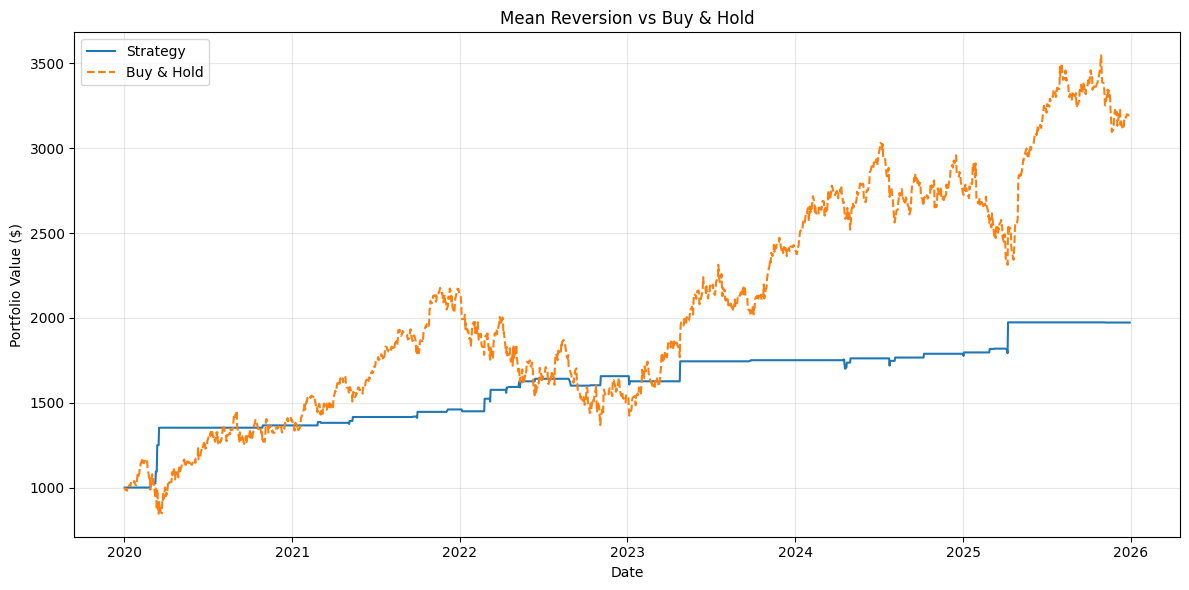

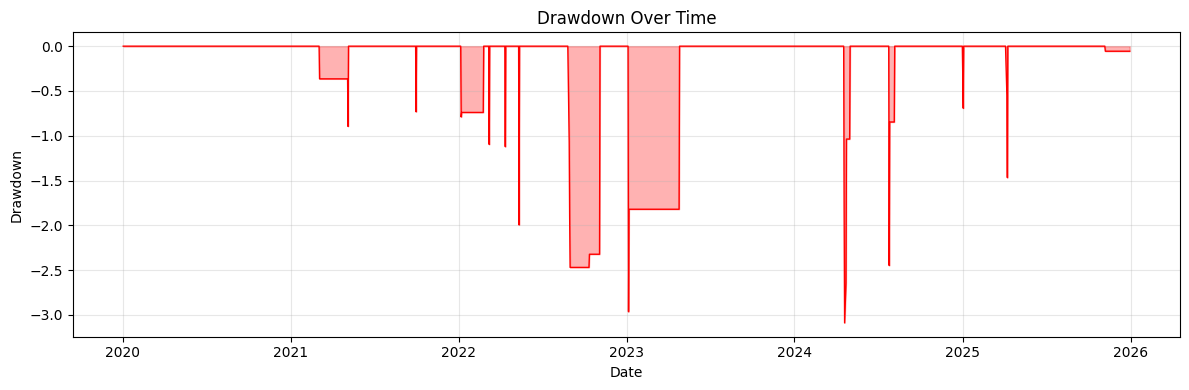

In [13]:
plot_equity_curve(results_raw["Mean Reversion"], data, title="Mean Reversion vs Buy & Hold")
plot_drawdown(results_raw["Mean Reversion"])

## Strategy 2

### Optimise Sharpe Ratio for momentum

Parameter: **lookback** period

Goal: Find the lookback period that optimises sharpe ratio 

88 :  0.9132718245456789


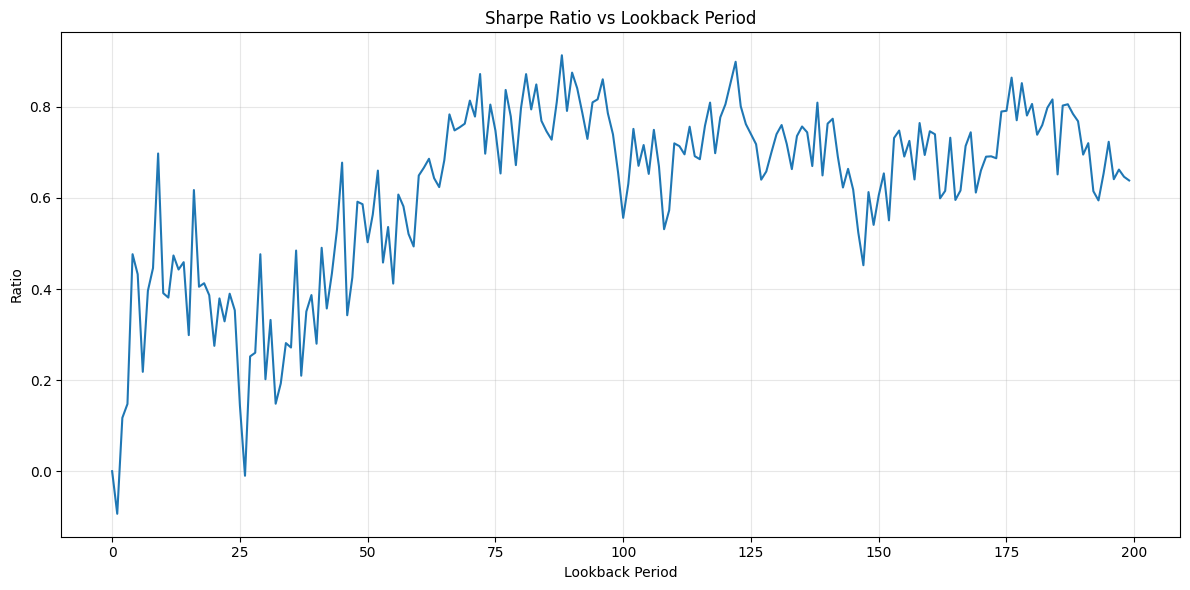

In [ ]:
sharpe_ratios = []
for period in range(200):
    result = backtester.run_backtest(data=data, strategy=MomentumStrategy(lookback=period))
    sharpe_ratios.append(metric_summary(result)["Sharpe Ratio"])

max_ratio = max(sharpe_ratios)
optimal_period = sharpe_ratios.index(max_ratio)

print(optimal_period, ": ", max_ratio)

plt.figure(figsize=(12, 6))
plt.plot(range(len(sharpe_ratios)), sharpe_ratios)
plt.title("Sharpe Ratio vs Lookback Period")
plt.xlabel("Lookback Period")
plt.ylabel("Ratio")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Strategy 3

### Optimise Sharpe Ratio for RSI

Parameter: 
1. **window** 
2. **oversold**

Goal: Find the optimal conditions to buy in     

In [41]:
results = []

for window in range(0, 50):
    # RSI only depends on window — compute once, reuse for every oversold threshold
    diff = data["Close"].diff()
    avg_gain = diff.where(diff > 0, 0).rolling(window).mean()
    avg_loss = diff.where(diff < 0, 0).rolling(window).mean().abs()
    rs = avg_gain / avg_loss
    rsi = (100 - (100 / (1 + rs)))

    for oversold in range(0, 50):
        signals = (rsi < oversold).astype(int)
        positions = signals.shift(1).fillna(0)
        returns = data["Close"].pct_change().fillna(0)
        strat_returns = positions * returns
        equity_curve = backtester.starting_capital * (1 + strat_returns).cumprod()

        eq_rets = equity_curve.pct_change().dropna()
        sharpe = 0.0 if eq_rets.std() == 0 else (eq_rets.mean() / eq_rets.std()) * (252 ** 0.5)

        results.append({"window": window, "oversold": oversold, "sharpe": sharpe})

results_df = pd.DataFrame(results)

results_df.sort_values("sharpe", ascending=False).head(15)

,window,oversold,sharpe
1187,23,37,1.419093
1186,23,36,1.386356
1136,22,36,1.291137
1238,24,38,1.285047
225,4,25,1.279480
1235,24,35,1.266179
229,4,29,1.259117
164,3,14,1.256671
1237,24,37,1.243039
1236,24,36,1.242391


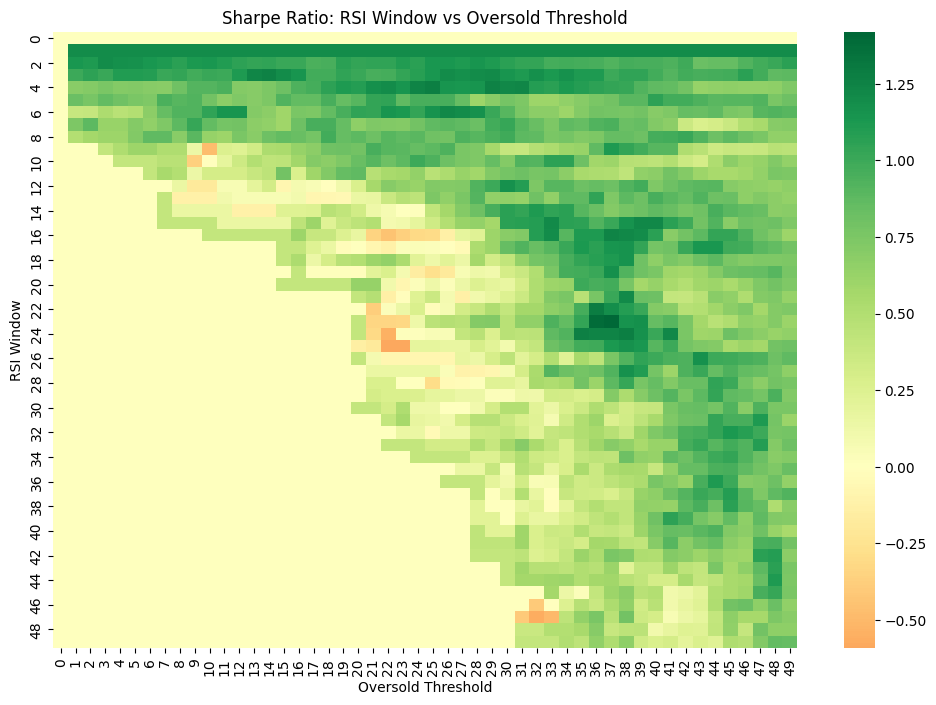

In [43]:
pivot = results_df.pivot(index="window", columns="oversold", values="sharpe")

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap="RdYlGn", center=0)
plt.title("Sharpe Ratio: RSI Window vs Oversold Threshold")
plt.xlabel("Oversold Threshold")
plt.ylabel("RSI Window")
plt.show()

Evalate the strategy for RSI(window = 23, oversold = 37)

In [42]:
result = backtester.run_backtest(data=data,strategy=RSIStrategy(window = 23, oversold=37))
print(metric_summary(result))

Total Return (%)         157.910994
Sharpe Ratio               1.419093
Max Drawdown (%)          -7.659975
Win Rate                   0.672727
Annualised Volatility      0.116304
dtype: float64


Perform this strategy on more stocks and on a different timeperiod

In [52]:
for ticker in ["MSFT","AAPL","GOOGL","AMZN","NVDA"]:
    data = loader.get_price_history(ticker=ticker,period = '5y')
    
    result = backtester.run_backtest(data=data,strategy=RSIStrategy(window = 23, oversold=37))
    results[ticker] = metric_summary(result)
    
pd.DataFrame(results).T.round(4)


        

    

,Total Return (%),Sharpe Ratio,Max Drawdown (%),Win Rate,Annualised Volatility
MSFT,89.1763,1.2435,-11.1078,0.6115,0.1076
AAPL,51.8628,0.6717,-15.7955,0.5556,0.1391
GOOGL,33.4963,0.5686,-12.4465,0.5468,0.1133
AMZN,30.6749,0.3912,-17.3340,0.5455,0.1766
NVDA,68.7625,0.7322,-20.4534,0.6067,0.1611


In [53]:
results = {}
for ticker in ["MSFT","AAPL","GOOGL","AMZN","NVDA"]:
    data = loader.get_price_history(ticker=ticker,period = '5y')
    
    result = backtester.run_backtest(data=data,strategy=BuyAndHold())
    results[ticker] = metric_summary(result)
    
pd.DataFrame(results).T.round(4)

,Total Return (%),Sharpe Ratio,Max Drawdown (%),Win Rate,Annualised Volatility
MSFT,44.6238,0.4097,-37.1485,0.5156,0.2697
AAPL,116.0042,0.6968,-33.3605,0.5332,0.2769
GOOGL,177.7810,0.8093,-44.3200,0.5296,0.3148
AMZN,35.1321,0.3477,-56.1453,0.5148,0.3571
NVDA,866.7044,1.1369,-66.3351,0.5319,0.5180
